In [4]:
import sys, os
import pathlib

root = pathlib.Path("../src").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from mltools         import MLConfig
from mltools.shared.logging import setup_logging
config = MLConfig.from_yaml("../configs/ml_config.yaml")
setup_logging(log_level=config.project.log_level,
              experiment=config.project.name)

TARGET    = config.data.target_column
ID_COLS   = config.data.id_columns
DATE_COLS = config.data.date_columns         

In [5]:
from mltools.data.loader import DataLoader
from mltools.preprocessing.inspector import DataInspector

df = DataLoader.load("../data/raw/dataset_full.csv")
inspector = DataInspector(df, target="phishing")
report = inspector.full_report()


03:36:28 | INFO     | mltools.data.loader:64 | Loading data dari ../data/raw/dataset_full.csv (format: .csv)
03:36:29 | SUCCESS  | mltools.data.loader:101 | Data loaded: 88,647 rows × 112 cols | 79.4 MB
03:36:29 | INFO     | mltools.preprocessing.inspector:30 | ============================================================
03:36:29 | INFO     | mltools.preprocessing.inspector:31 | MEMULAI FULL DATA INSPECTION
03:36:29 | INFO     | mltools.preprocessing.inspector:32 | ============================================================

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 BASIC INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  shape                    : (88647, 112)
  n_rows                   : 88647
  n_cols                   : 112
  memory_usage_mb          : 79.43
  dtypes_count             : {dtype('int64'): 111, dtype('float64'): 1}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔢 DTYPE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

,column,dtype,pandas_type,memory_mb
0,qty_dot_url,int64,integer,0.7093
1,qty_hyphen_url,int64,integer,0.7093
2,qty_underline_url,int64,integer,0.7093
3,qty_slash_url,int64,integer,0.7093
4,qty_questionmark_url,int64,integer,0.7093
...,...,...,...,...
107,qty_redirects,int64,integer,0.7093
108,url_google_index,int64,integer,0.7093
109,domain_google_index,int64,integer,0.7093
110,url_shortened,int64,integer,0.7093



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
❓ MISSING VALUES ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Tidak ada missing values!

  Total missing cells : 0 / 9,928,464 (0.00%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🔁 DUPLICATE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Duplicate rows : 1,438 (1.62%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 CARDINALITY ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,column,n_unique,unique_pct,dtype,cardinality
97,time_response,80207,90.48,float64,HIGH CARD ⚠
105,ttl_hostname,10171,11.47,int64,HIGH CARD ⚠
100,time_domain_activation,8790,9.92,int64,HIGH CARD ⚠
99,asn_ip,3638,4.10,int64,HIGH CARD ⚠
101,time_domain_expiration,3093,3.49,int64,HIGH CARD ⚠
...,...,...,...,...,...
27,qty_exclamation_domain,1,0.00,int64,CONSTANT ⛔
31,qty_plus_domain,1,0.00,int64,CONSTANT ⛔
29,qty_tilde_domain,1,0.00,int64,CONSTANT ⛔
30,qty_comma_domain,1,0.00,int64,CONSTANT ⛔



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 STATISTICAL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
count,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,...,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000,88647.0000
mean,2.1913,0.3288,0.1139,1.2818,0.0093,0.2059,0.0221,0.1409,0.0029,0.0010,...,1.1366,2.7724,1.7424,6159.8775,0.5064,0.3439,0.0014,0.0020,0.0055,0.3457
std,1.2356,1.1193,0.6578,1.8939,0.1126,0.9543,0.2797,0.9249,0.0873,0.0727,...,0.8951,1.3230,1.7067,11465.5838,0.5000,0.7839,0.0586,0.0633,0.0738,0.4756
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,-1.0000,0.0000,0.0000,-1.0000,0.0000,-1.0000,-1.0000,-1.0000,0.0000,0.0000
1%,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,-1.0000,1.0000,0.0000,-1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
5%,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,-1.0000,2.0000,0.0000,-1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000
25%,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.0000,2.0000,1.0000,292.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.0000,2.0000,1.0000,2029.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,2.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,1.0000,4.0000,2.0000,10798.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000
95%,4.0000,2.0000,1.0000,5.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,...,2.0000,5.0000,5.0000,21587.0000,1.0000,2.0000,0.0000,0.0000,0.0000,1.0000



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 TARGET VARIABLE ANALYSIS: 'phishing'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Task Type: CLASSIFICATION
  Class Distribution:
phishing
0    58000
1    30647
Name: count, dtype: int64

  Imbalance Ratio: 1.89x
03:36:30 | INFO     | mltools.preprocessing.inspector:41 | ============================================================
03:36:30 | INFO     | mltools.preprocessing.inspector:42 | INSPEKSI SELESAI
03:36:30 | INFO     | mltools.preprocessing.inspector:43 | ============================================================


Temuan :
- Tidak ada missing values 
- Terdapat Duplicates rows
- Terdapat kolom kardinalitas n_unique 1 (constant)
- Terdapat kolom dengan nilai negatif(-1)

03:38:15 | INFO     | mltools.data.eda:60 | EDAVisualizer init: (88647, 112) | num=111 cat=0 target=phishing
03:38:15 | INFO     | mltools.data.eda:452 | Running Full EDA Visualization...
03:38:15 | INFO     | mltools.data.eda:453 | Output → reports/
03:38:15 | INFO     | mltools.data.eda:76 | Tidak ada missing values — skip heatmap


03:38:15 | INFO     | mltools.data.eda:386 | Imbalance ratio: 1.9x — cukup seimbang
03:38:15 | INFO     | mltools.data.eda:397 | Saved: reports\target_distribution.png


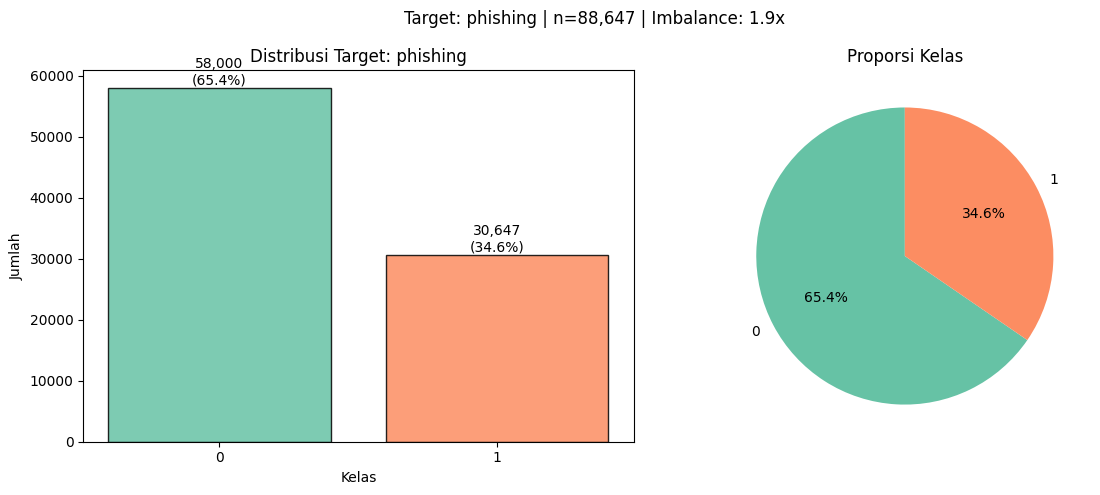

03:38:20 | INFO     | mltools.data.eda:168 | Saved: reports\distributions.png


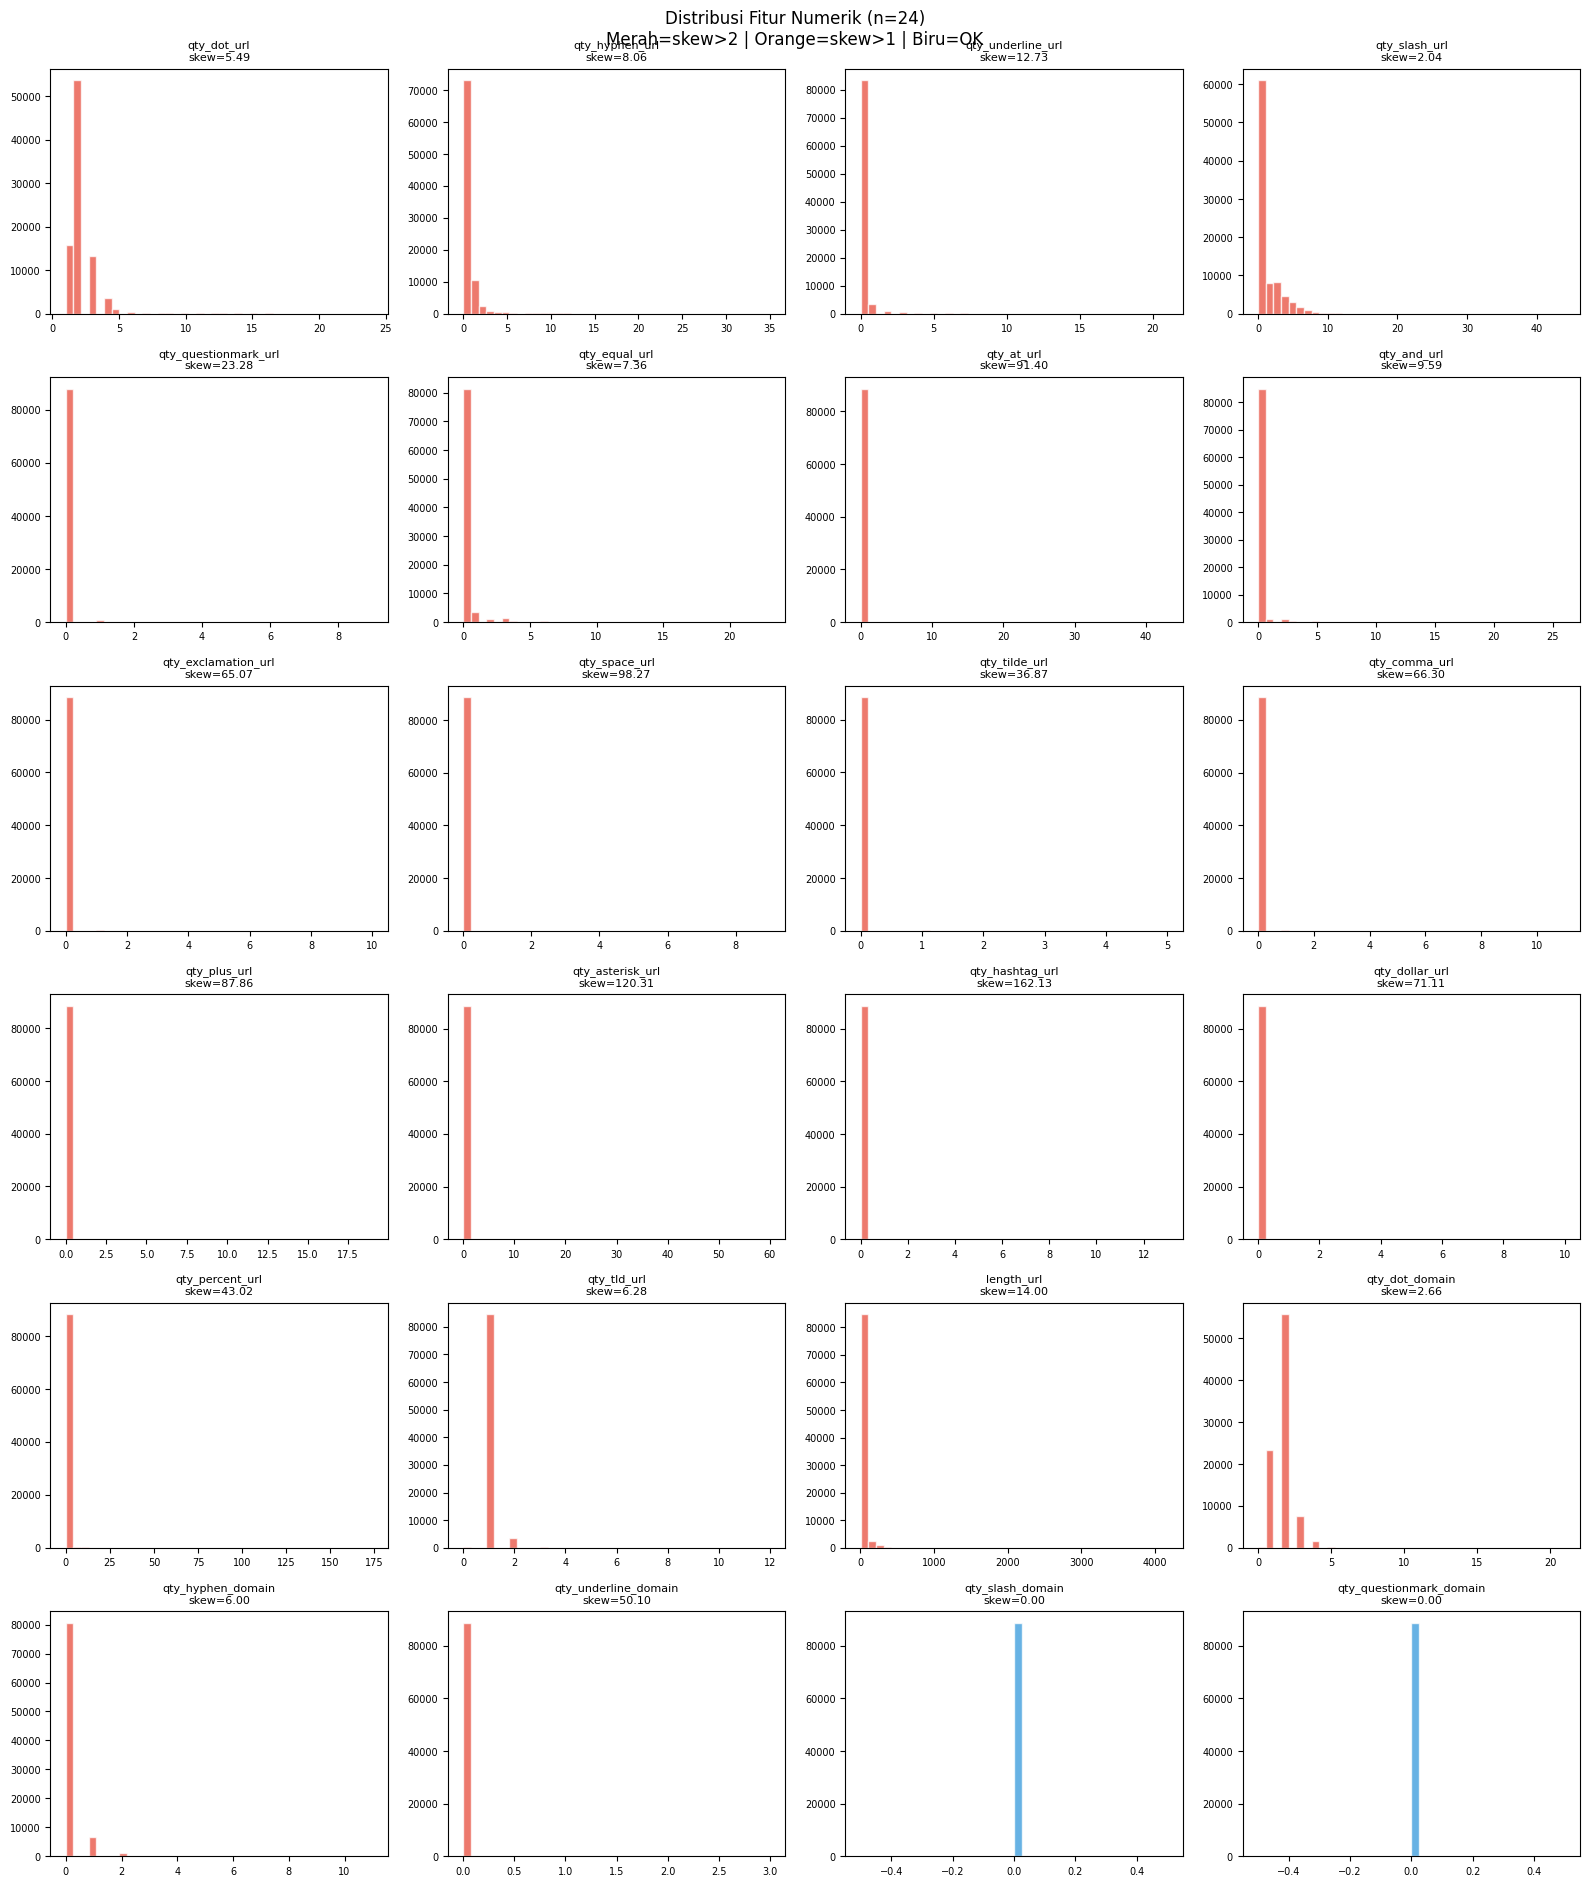

03:38:25 | INFO     | mltools.data.eda:439 | Saved: reports\boxplots.png


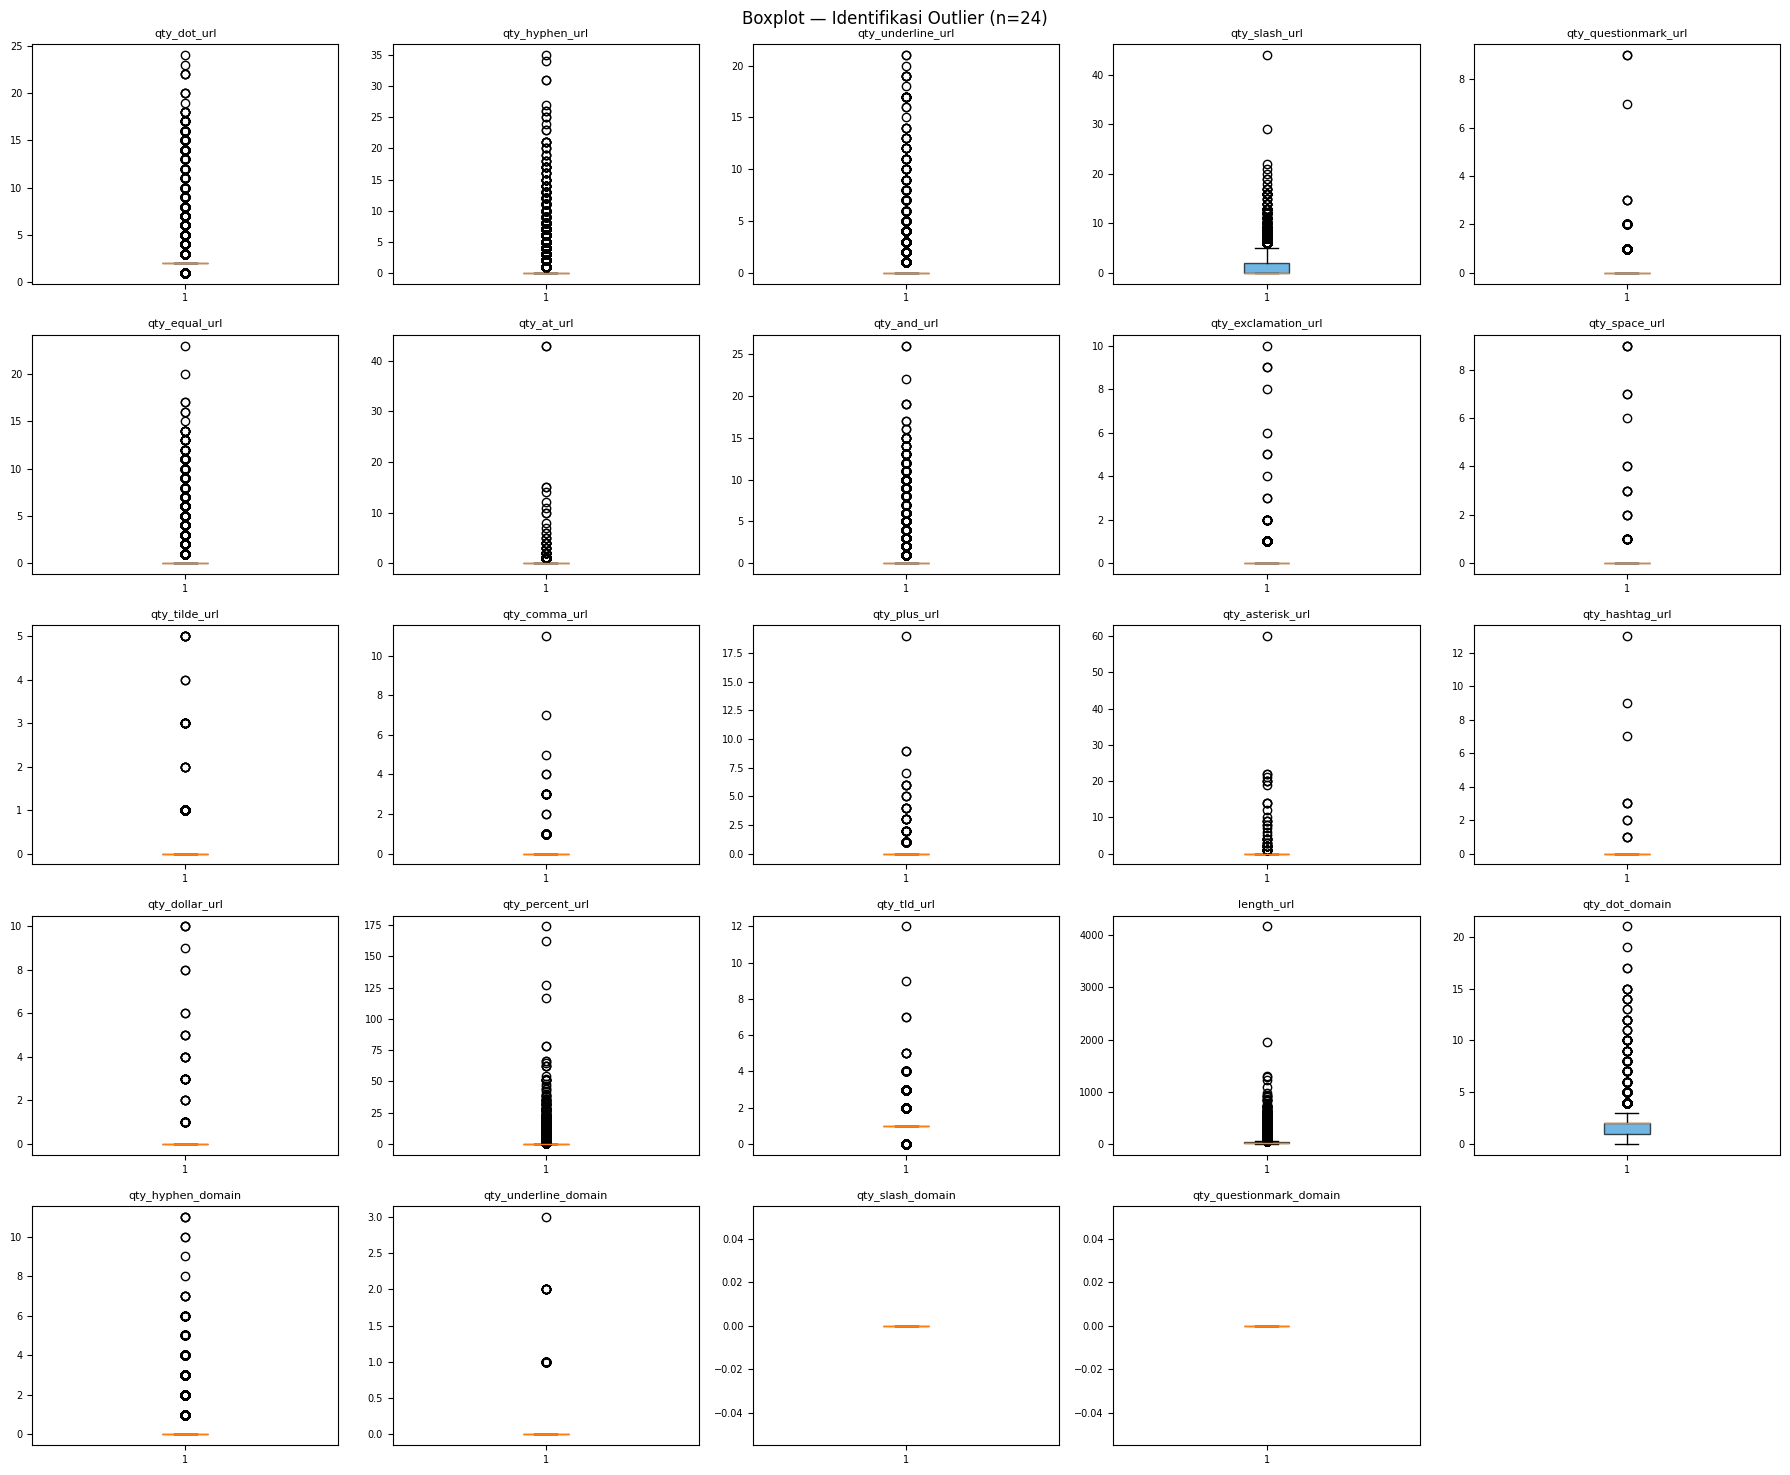

03:38:28 | INFO     | mltools.data.eda:222 | Saved: reports\correlation_matrix.png


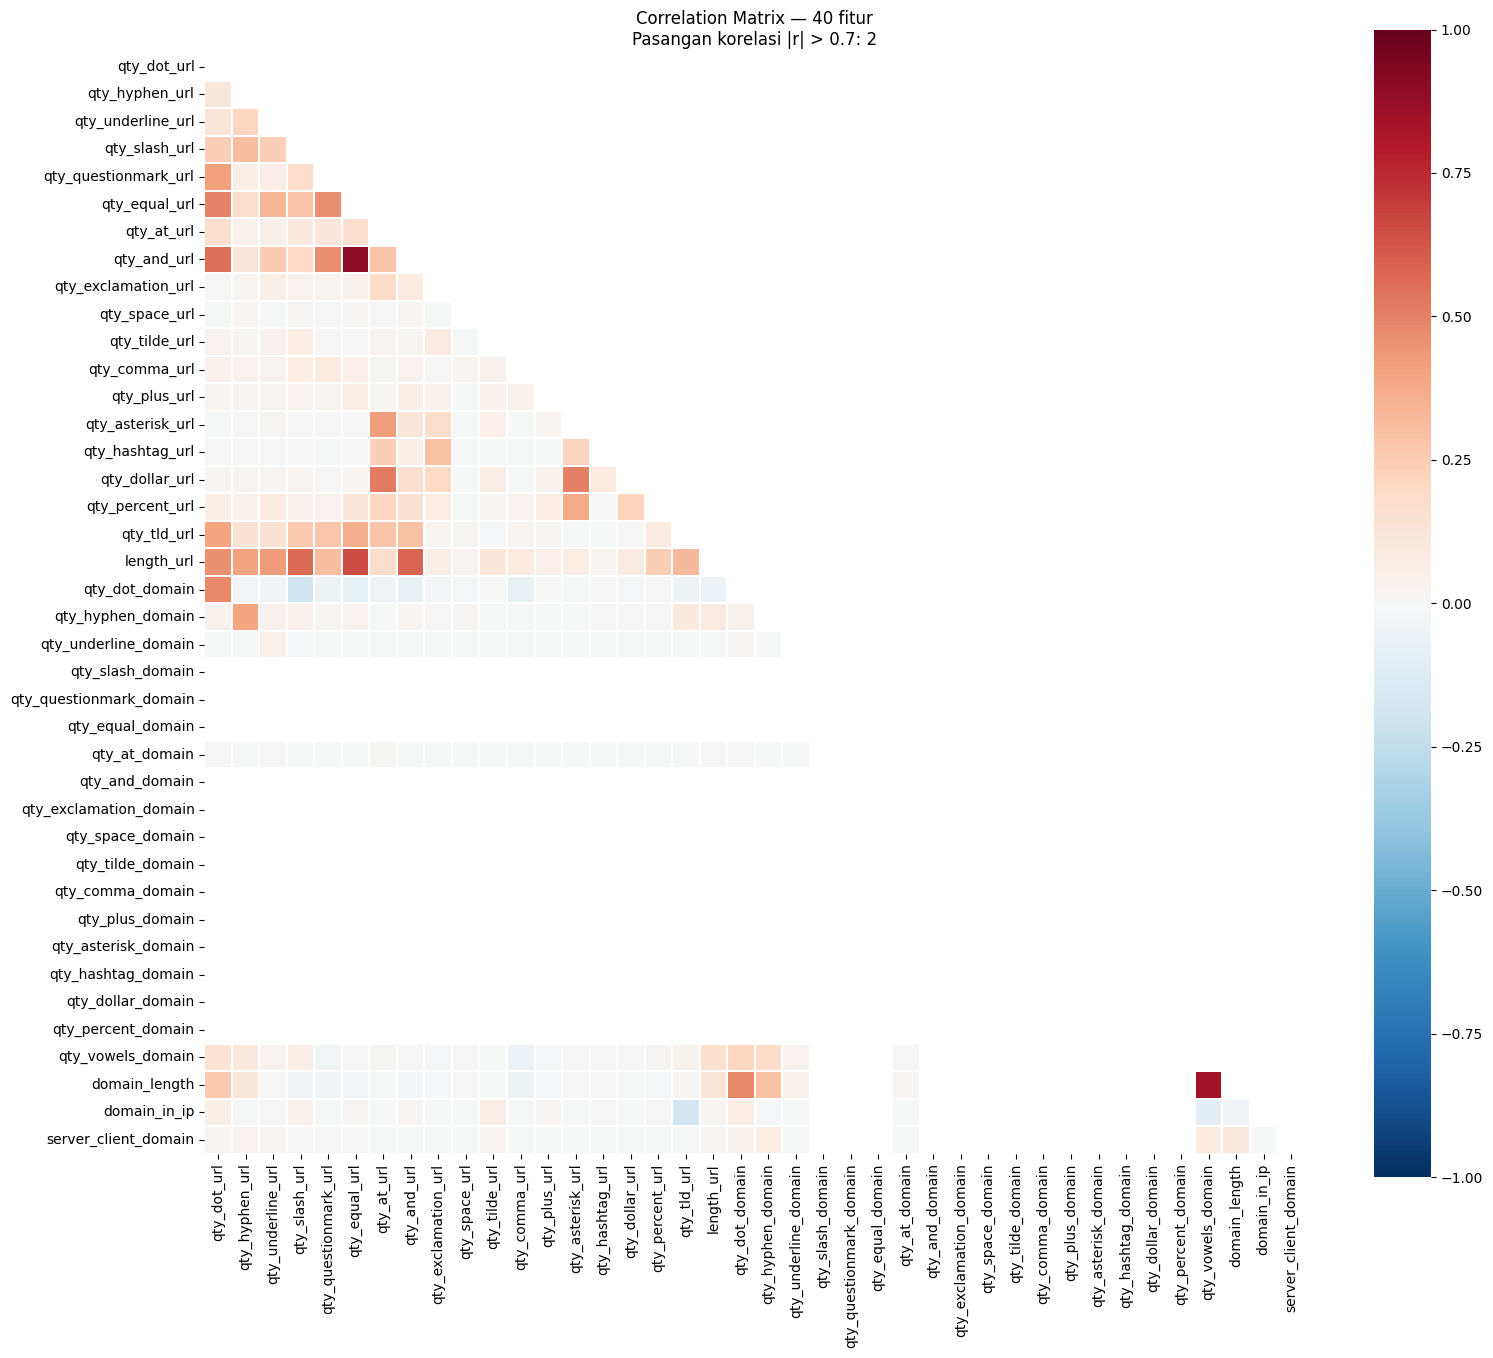

03:38:28 | WARNING  | mltools.data.eda:227 | Ditemukan 2 pasangan fitur dengan |r| > 0.7:
03:38:28 | WARNING  | mltools.data.eda:235 |   qty_and_url ↔ qty_equal_url: r=0.8927
03:38:28 | WARNING  | mltools.data.eda:235 |   domain_length ↔ qty_vowels_domain: r=0.8386
03:38:35 | INFO     | mltools.data.eda:341 | Saved: reports\target_vs_features.png


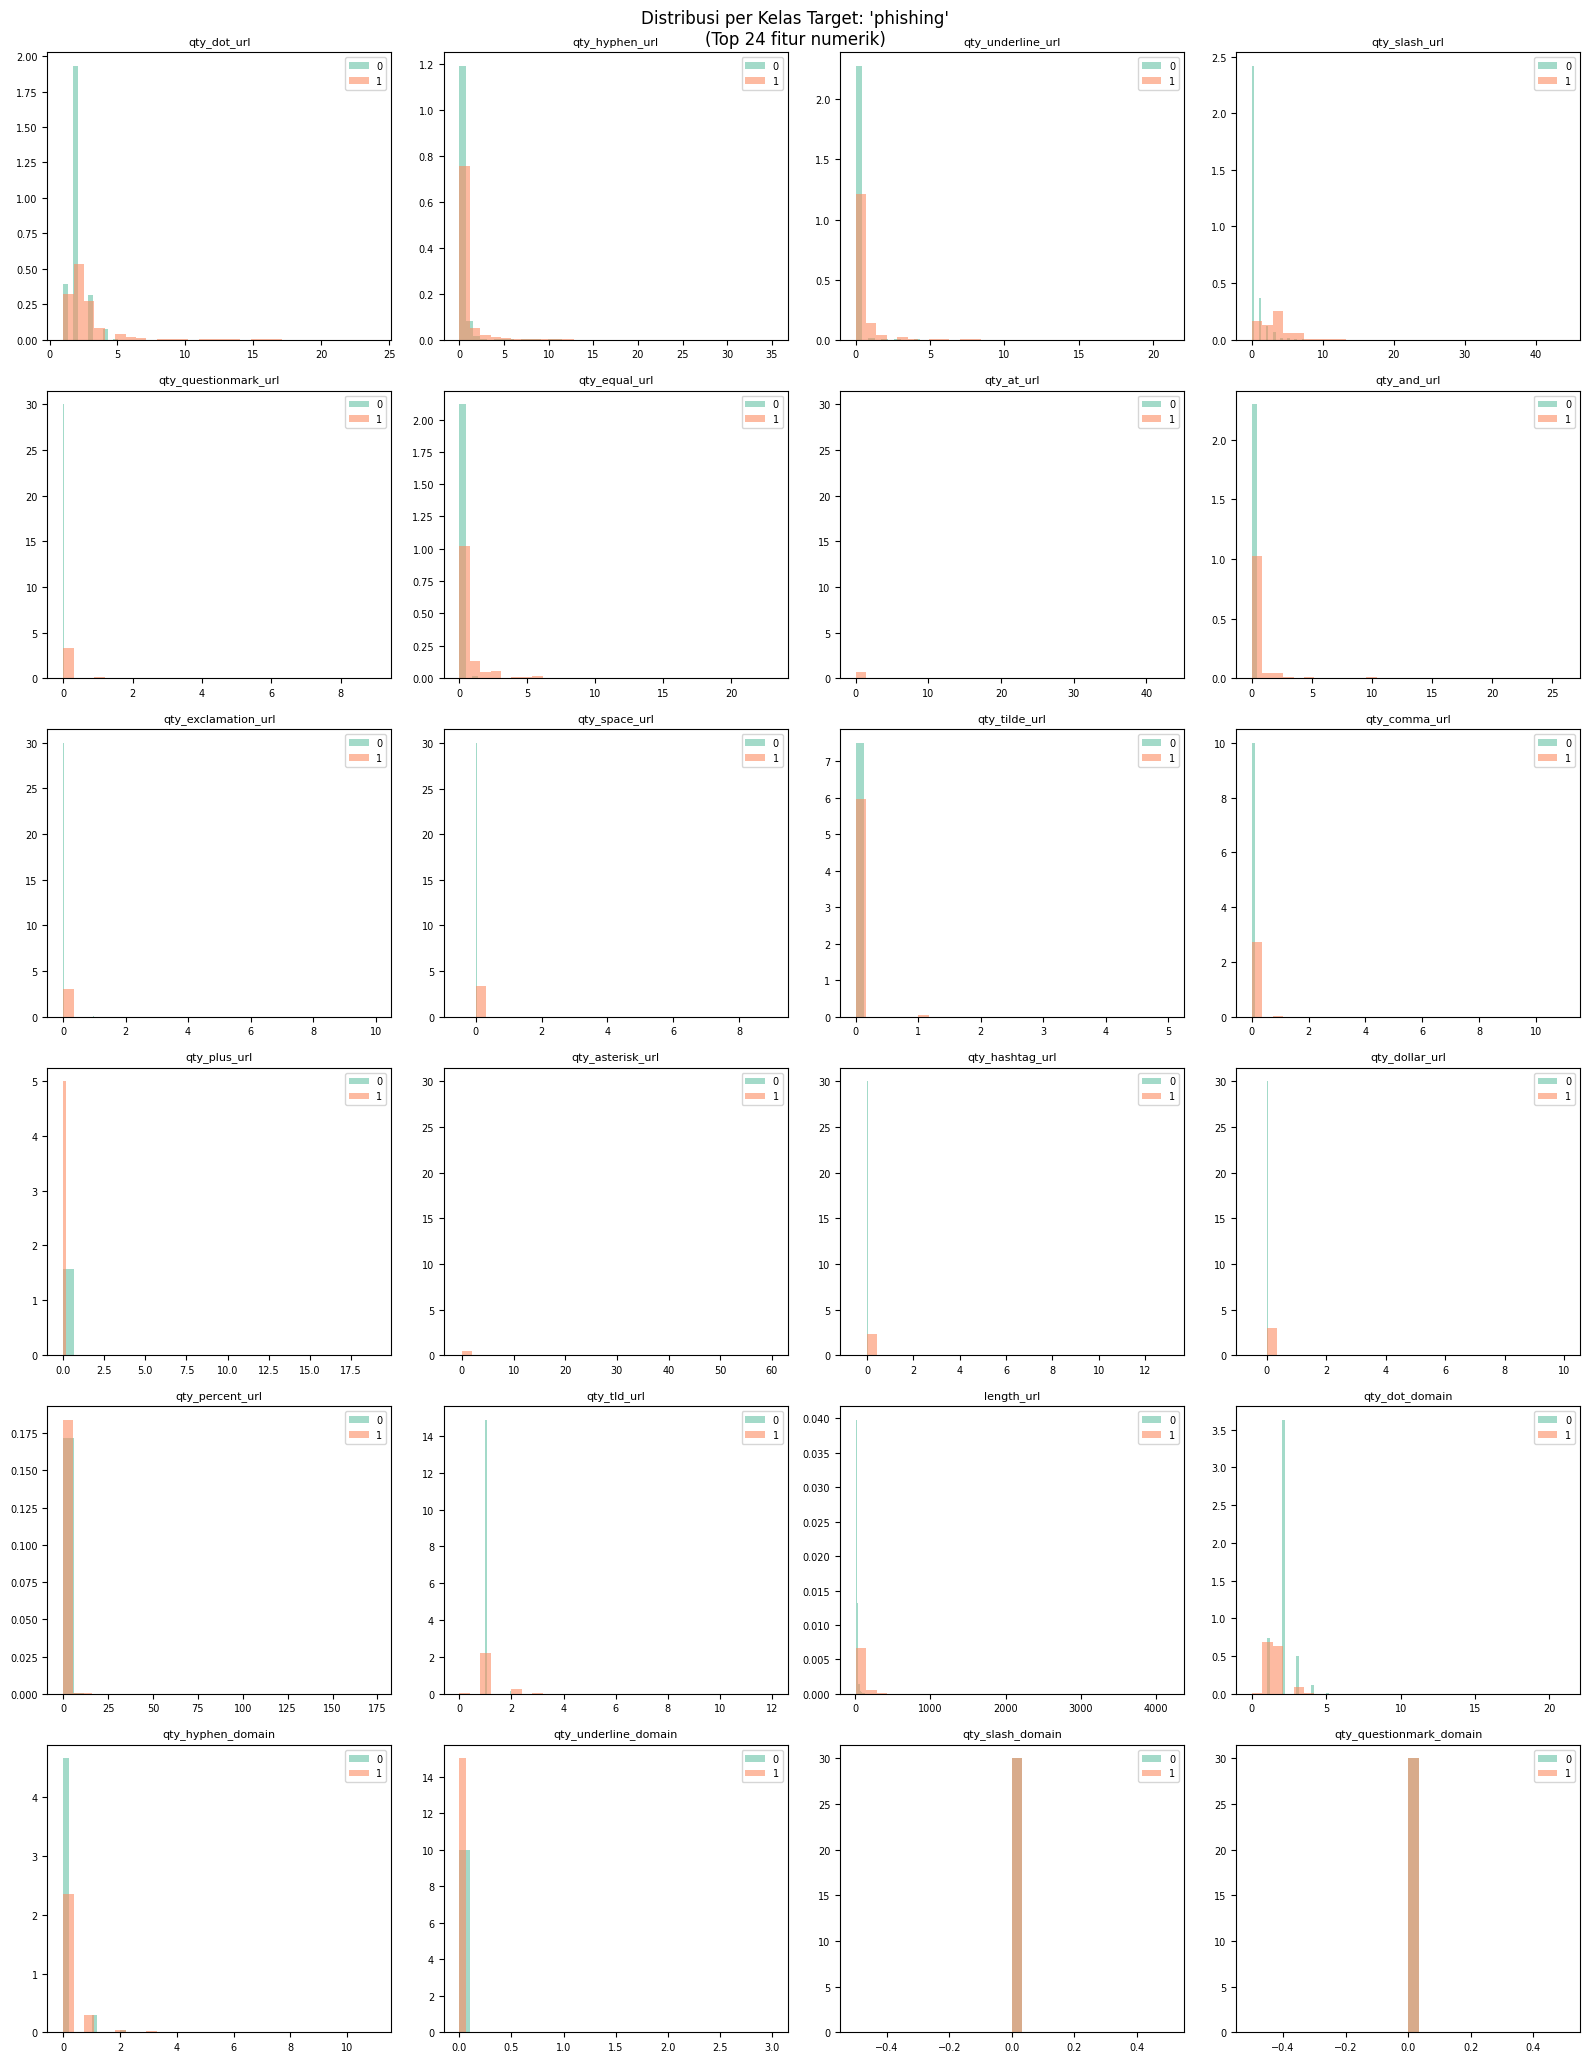

03:38:37 | SUCCESS  | mltools.data.eda:470 | Full EDA selesai! Semua plot tersimpan di reports/


In [7]:
from mltools.data.eda import EDAVisualizer
eda = EDAVisualizer(df, target="phishing")
eda.run_full_eda()

Temuan : 
- Banyak data right-skewed
- Terdapat fitur yang correlationnya NaN
- Fitur berkorelasi tinggi : [{'feature_1': 'qty_equal_url', 'feature_2': 'qty_and_url', 'correlation': np.float64(0.8927)}]